In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import GMM

In [2]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go

In [3]:
# Import Data
SPdata = pd.read_pickle('PreparedData/sp500_scaled_features.pkl')
SPdata

,RR,VCR,VIXD,TBRD,OASD
Date,,,,,
2005-01-04,-0.998106,0.710584,-0.052235,1.114678,-0.827652
2005-01-05,-0.327900,0.055695,0.057407,-0.105830,0.644412
2005-01-06,0.261986,-0.561942,-0.266298,-0.088142,0.460404
2005-01-07,-0.145809,-0.327823,-0.047014,0.230252,-0.183624
2005-01-10,0.255140,0.045183,-0.135772,-0.123517,0.276396
...,...,...,...,...,...
2025-12-23,0.348006,-0.852081,-0.041793,0.000302,-0.459636
2025-12-24,0.238551,-4.116138,-0.276740,-0.583417,0.092388
2025-12-26,-0.052558,1.984294,0.067849,0.000302,0.184392


In [4]:
# Split Dataset
X_train = tf.cast(SPdata[:'2021-12-31'], dtype = tf.float32)
X_test = tf.cast(SPdata['2022-01-01':'2023-12-31'], dtype = tf.float32)
X_CV = tf.cast(SPdata['2024-01-01':], dtype = tf.float32)

## Start Training --- Find the best K

In [5]:
K_list = [2,3,4,5,6,7]
Result = []
for idx, K in enumerate(K_list):
    print(f'--- Training Classifier: Number of Centroids K = {K}. Round: ({idx+1}/{len(K_list)})---')
    print("K-Means Initialization...")
    kmeans = GMM.TF_kmeans(K)
    mu_init, pi_init, sigma_init = kmeans.gmm_init_params(X_train)

    print("Running GMM Training...")
    gmm = GMM.TF_GMM(K, max_iters=150, tol=1e-4)
    gamma, log_likelihood, aic, bic = gmm.fit(X_train, mu_init, pi_init, sigma_init, verbose=True)
    Result.append([K, log_likelihood, aic, bic])
    print(f'--- End of Round {idx + 1} ---'+'\n')

--- Training Classifier: Number of Centroids K = 2. Round: (1/6)---
K-Means Initialization...
Running GMM Training...
---GMM training---
Iteration:   0 | Log_likelihood: -25320.4688 | Shift: inf
Iteration:   5 | Log_likelihood: -22098.8945 | Shift: 7.046875
Iteration:  10 | Log_likelihood: -22091.3281 | Shift: 0.378906
Iteration:  15 | Log_likelihood: -22090.8203 | Shift: 0.025391
Iteration:  20 | Log_likelihood: -22090.7773 | Shift: 0.003906
---Iteration end at 21.---

--- Model Metrics ---
Total Params : 41
Final Log-L  : -22090.7773
AIC          : 44263.5547
BIC          : 44524.3086
--- End of Round 1 ---

--- Training Classifier: Number of Centroids K = 3. Round: (2/6)---
K-Means Initialization...
Running GMM Training...
---GMM training---
Iteration:   0 | Log_likelihood: -23776.9609 | Shift: inf
Iteration:   5 | Log_likelihood: -21620.6230 | Shift: 59.685547
Iteration:  10 | Log_likelihood: -21480.9766 | Shift: 14.117188
Iteration:  15 | Log_likelihood: -21454.4414 | Shift: 2.148

In [7]:
Result_df = pd.DataFrame(Result, columns=['K','Log_likelihood', 'AIC', 'BIC']).set_index('K')
Result_df

,Log_likelihood,AIC,BIC
K,,,
2,-22090.777344,44263.554688,44524.308594
3,-21449.910156,43023.820312,43418.128906
4,-21092.570312,42351.140625,42879.007812
5,-20987.720703,42183.441406,42844.863281
6,-20899.167969,42048.335938,42843.316406
7,-20844.238281,41980.476562,42909.011719


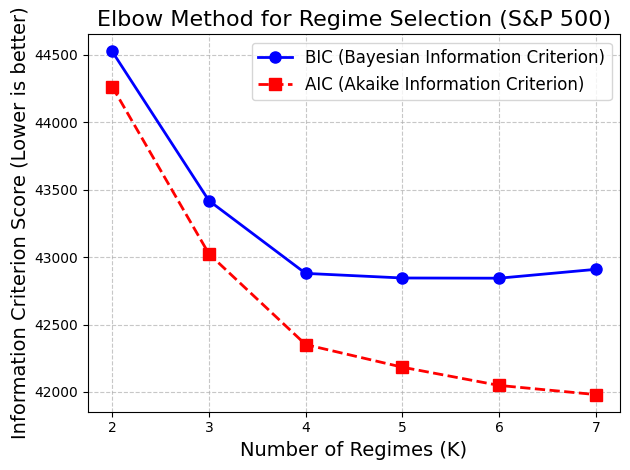

In [ ]:
#Elbow Plot
plt.plot(Result_df.index, Result_df['BIC'], 'b-o', linewidth=2, markersize=8, label='BIC (Bayesian Information Criterion)')

plt.plot(Result_df.index, Result_df['AIC'], 'r--s', linewidth=2, markersize=8, label='AIC (Akaike Information Criterion)')

plt.title('Elbow Method for Regime Selection (S&P 500)', fontsize=16)
plt.xlabel('Number of Regimes (K)', fontsize=14)
plt.ylabel('Information Criterion Score (Lower is better)', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(Result_df.index)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

### Best K

In [ ]:
K_regimes = 4

print("Running K-Means Initialization...")
kmeans = GMM.TF_kmeans(K=K_regimes)
mu_init, pi_init, sigma_init = kmeans.gmm_init_params(X_train)

print("Running GMM Training...")
gmm = GMM.TF_GMM(K=K_regimes, max_iters=150, tol=1e-4)
gamma, log_likelihood, aic, bic = gmm.fit(X_train, mu_init, pi_init, sigma_init, verbose=True)

Running K-Means Initialization...
Running GMM Training...
---GMM training---
Iteration:   0 | Log_likelihood: -23057.1074 | Shift: inf
Iteration:   5 | Log_likelihood: -21800.8633 | Shift: 76.679688
Iteration:  10 | Log_likelihood: -21494.4609 | Shift: 44.804688
Iteration:  15 | Log_likelihood: -21310.9160 | Shift: 29.435547
Iteration:  20 | Log_likelihood: -21239.6367 | Shift: 11.140625
Iteration:  25 | Log_likelihood: -21187.1367 | Shift: 9.734375
Iteration:  30 | Log_likelihood: -21150.5645 | Shift: 6.171875
Iteration:  35 | Log_likelihood: -21126.1406 | Shift: 4.070312
Iteration:  40 | Log_likelihood: -21111.0977 | Shift: 2.419922
Iteration:  45 | Log_likelihood: -21101.6621 | Shift: 1.583984
Iteration:  50 | Log_likelihood: -21095.8730 | Shift: 0.857422
Iteration:  55 | Log_likelihood: -21093.6074 | Shift: 0.251953
Iteration:  60 | Log_likelihood: -21092.9883 | Shift: 0.072266
Iteration:  65 | Log_likelihood: -21092.7695 | Shift: 0.031250
Iteration:  70 | Log_likelihood: -21092.67

In [14]:
SP_test = pd.read_csv('RawData/sp500_market_features_2005_2025.csv', index_col= 0, parse_dates=True)
SP_test['RR'] = np.log(SP_test['Close'] / SP_test['Close'].shift(1))
SP_test = SP_test['2005-01-04':'2021-12-31']
SP_test

,Close,TBR,VIX,Volume,OAS,RR
Date,,,,,,
2005-01-04,1188.050049,4.283,13.980000,1721000000,2.97,-0.011740
2005-01-05,1183.739990,4.277,14.090000,1738900000,3.04,-0.003634
2005-01-06,1187.890015,4.272,13.580000,1569100000,3.09,0.003500
2005-01-07,1186.189941,4.285,13.490000,1477900000,3.07,-0.001432
2005-01-10,1190.250000,4.278,13.230000,1490400000,3.10,0.003417
...,...,...,...,...,...,...
2021-12-27,4791.189941,1.481,17.680000,2770290000,3.02,0.013744
2021-12-28,4786.350098,1.481,17.540001,2707920000,3.01,-0.001011
2021-12-29,4793.060059,1.543,16.950001,2963310000,3.03,0.001401


In [ ]:
# 'Hard Label'
hard_labels = tf.argmax(gamma, axis=1).numpy()
SP_test.reset_index(inplace=True)
SP_test['Regime'] = hard_labels
SP_test.head()

,Date,Close,TBR,VIX,Volume,OAS,RR,Regime
0,2005-01-04,1188.050049,4.283,13.98,1721000000,2.97,-0.011740,2
1,2005-01-05,1183.739990,4.277,14.09,1738900000,3.04,-0.003634,3
2,2005-01-06,1187.890015,4.272,13.58,1569100000,3.09,0.003500,3
3,2005-01-07,1186.189941,4.285,13.49,1477900000,3.07,-0.001432,3
4,2005-01-10,1190.250000,4.278,13.23,1490400000,3.10,0.003417,3


In [18]:
feature_cols = ['Close', 'TBR', 'VIX', 'Volume', 'OAS','RR']
print("\n--- Regime Profiling (Factor Means) ---")
regime_profile = SP_test.groupby('Regime')[feature_cols].mean()
print(regime_profile)


--- Regime Profiling (Factor Means) ---
              Close       TBR        VIX        Volume        OAS        RR
Regime                                                                     
0       1688.046047  2.447979  41.168571  6.078463e+09  10.665210 -0.002666
1       1918.253754  2.801186  16.555494  3.451294e+09   4.898379  0.000582
2       1891.377494  2.688605  21.686575  4.208007e+09   5.969226 -0.000459
3       2033.602984  2.824143  15.529940  3.362932e+09   4.472533  0.001092


In [ ]:
color_map = {0: 'red', 1: 'gray', 2: 'green'} 
regime_names = {
    0: 'Regime 0 ', 
    1: 'Regime 1 ', 
    2: 'Regime 2 '
}

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=SP_test['Date'],
    y=SP_test['Close'],
    mode='lines',
    name='S&P 500 Trend',
    line=dict(color='black', width=1),
    opacity=0.3, 
    hoverinfo='skip' 
))


for regime in sorted(SP_test['Regime'].unique()):
    mask = SP_test['Regime'] == regime
    
    fig.add_trace(go.Scatter(
        x=SP_test[mask]['Date'],
        y=SP_test[mask]['Close'],
        mode='markers',
        name=regime_names.get(regime, f'Regime {regime}'),
        marker=dict(
            color=color_map.get(regime, 'blue'), 
            size=5, 
            line=dict(width=0.5, color='white') 
        )
        hovertemplate='<b>日期:</b> %{x}<br>' +
                      '<b>标普500:</b> %{y:.2f}<br>' +
                      '<b>状态:</b> ' + regime_names.get(regime, f'Regime {regime}') +
                      '<extra></extra>'
    ))

fig.update_layout(
    title=dict(
        text='<b>S&P 500 Market Regimes Identified by GMM</b>',
        font=dict(size=20)
    ),
    xaxis_title='Date',
    yaxis_title='Close Price',
    template='plotly_white', 
    hovermode='closest',     
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor="rgba(255, 255, 255, 0.8)" 
    )
)
fig.update_xaxes(rangeslider_visible=True)
fig.show()